# Trajectory with STREAM2
 Stream2 trajectory and extract macrostates

Change the parameters here : 

In [9]:
# === PARAMETERS ===
input_file = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Matrix/p2_test.h5ad"
patient = "P2"
output_directory = "/home/a.blanc-boekholt/Documents/Singlecell-R/Scripts/Plots"
reduction='X_umap' # Reduction on which trajectory learning is based (X_umap, X_pca, X_tsne)
nb_node= 50 # Number of nodes on the trajectory graph (80)
nb_cluster= 30 # Number of cluster on the trajectory graph -> ramification (120)

In [86]:
#!pip uninstall stream2 -y
#!pip install git+https://github.com/pinellolab/STREAM2.git
# Restart the kernel
import stream2 as st2
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import KDEpy
from sklearn.neighbors import NearestNeighbors
#!pip3 install leidenalg
#!pip install KDEpy

In [3]:
adata = sc.read(input_file)

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/anndata/_io/h5ad.py:266: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{


In [4]:
print(adata.obs["timepoint"].head())

D1_AAACCCAAGTCCCGAC-1    D1
D1_AAACCCACATAGCACT-1    D1
D1_AAACCCACATGGCCCA-1    D1
D1_AAACCCAGTCTTTCTA-1    D1
D1_AAACCCAGTTCTAAGC-1    D1
Name: timepoint, dtype: object


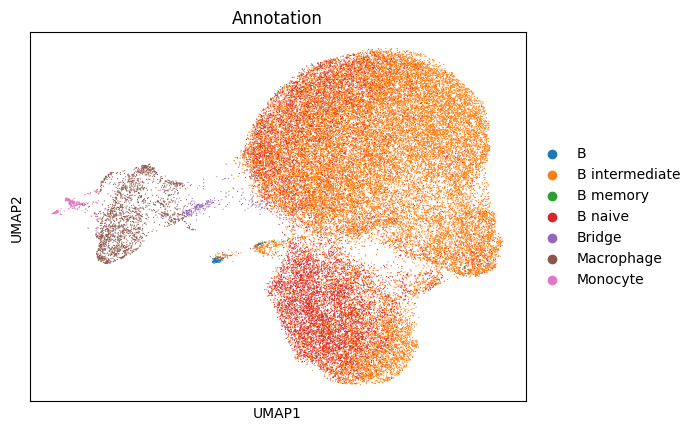

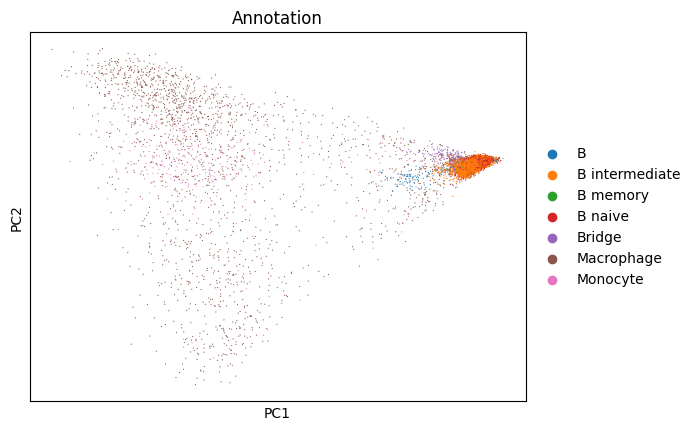

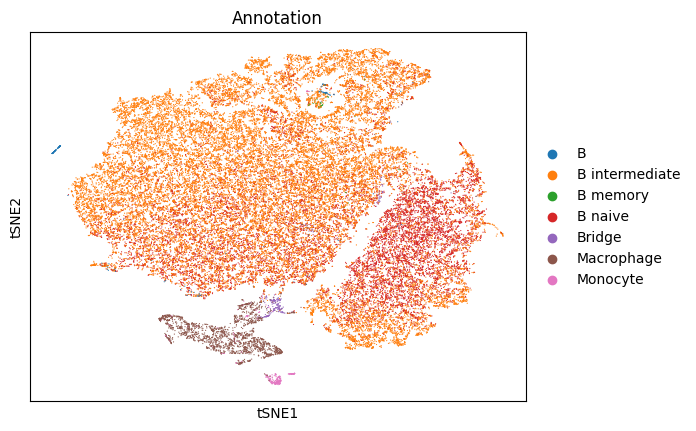

In [5]:
sc.pl.umap(adata,color=['Annotation'])
sc.pl.pca(adata,color=['Annotation'])
sc.pl.tsne(adata,color=['Annotation'])

/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:940: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():


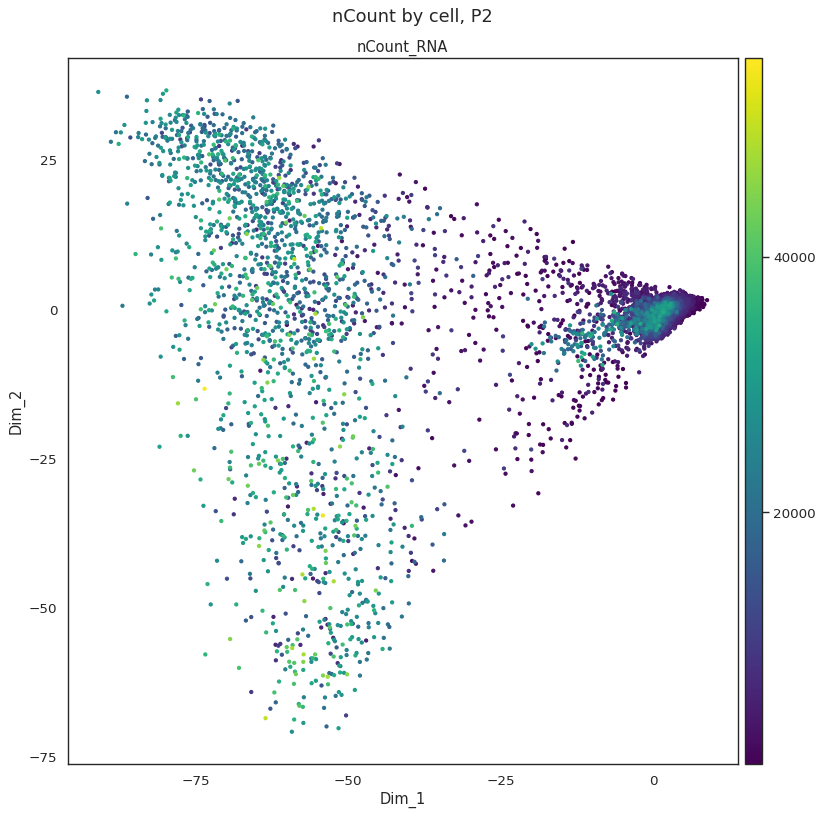

In [6]:
adata.obsm['X_dr'] = adata.obsm['X_pca']
st2.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

st2.pl.dimension_reduction(adata,color=['nCount_RNA'],
                           fig_legend_ncol=2, fig_size=(10,10))
plt.suptitle(f"nCount by cell, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/ncount_{patient}.png", dpi=300, bbox_inches='tight')

Found 1 components


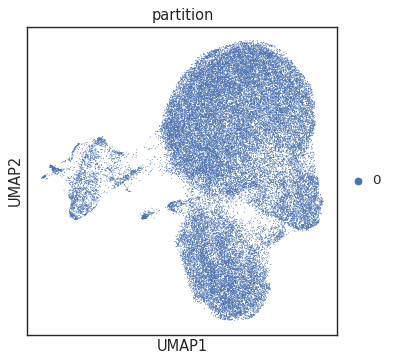

In [75]:
sc.pp.neighbors(adata,use_rep='X_pca',n_neighbors=10)
sc.tl.leiden(adata)
st2.tl.find_disconnected_components(adata,groups='leiden')
sc.pl.umap(adata,color='partition')

<Axes: xlabel='partition'>

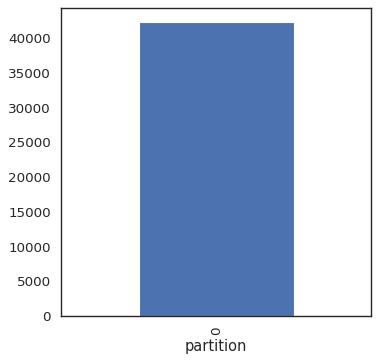

In [7]:
# Many are small clusters which are not adequate for trajectory inference and can be filtered out
# We keep components with more than 500 cells
adata.obs['partition'].value_counts().plot.bar()

In [76]:
use_partition=['0']
dict_palette = {"D1": "#1f77b4", "D4": "#2ca02c", "D8": "#ff7f0e", "D11": "#d62728", "D14": "#9467bd"}
adata.obs["timepoint"] = adata.obs["timepoint"].astype(str)
adata.obs["timepoint"] = pd.Categorical(adata.obs["timepoint"],categories=["D1", "D4", "D8", "D11", "D14"],ordered=True) 

st2.tl.seed_graph(adata, obsm=f"{reduction}", n_clusters=120,use_partition=use_partition)
st2.tl.learn_graph(adata, obsm=f"{reduction}", n_nodes=20,epg_alpha=0.01,epg_mu=0.2,use_partition=use_partition)
st2.pl.graph(adata,key='epg',color=['Annotation'],dict_palette=dict_palette,fig_size=(15,10),save_fig=False)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_myel_{patient}.png", dpi=300, bbox_inches='tight')

fig, ax = plt.subplots(figsize=(15, 10))
sc.pl.umap(adata,color="timepoint",palette=dict_palette,show=False, ax=ax, size=15)
epg = adata.uns["epg"]
nodes = epg["node_pos"]
edges = epg["edge"]
for edge in edges:
    p1 = nodes[edge[0]]
    p2 = nodes[edge[1]]
    ax.plot([p1[0], p2[0]],[p1[1], p2[1]],color="black",linewidth=1.5,zorder=10)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_time_{patient}.png", dpi=500, bbox_inches='tight')  
plt.close()
#adata_sub.uns['epg']['leaves']

st2.tl._elpigraph._store_graph_attributes(adata,adata.obsm[f"{reduction}"],'epg')
st2.pl.graph(adata,key='epg',color=['Annotation'],show_text=True,fig_size=(8,5),save_fig=False)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_v2_myel_{patient}.png", dpi=300, bbox_inches='tight')
fig, ax = plt.subplots(figsize=(15, 10))
sc.pl.umap(adata,color="timepoint",palette=dict_palette,show=False, ax=ax, size=15)
epg = adata.uns["epg"]
nodes = epg["node_pos"]
edges = epg["edge"]
for edge in edges:
    p1 = nodes[edge[0]]
    p2 = nodes[edge[1]]
    ax.plot([p1[0], p2[0]],[p1[1], p2[1]],color="black",linewidth=1.5,zorder=10)
ax.scatter(nodes[:, 0],nodes[:, 1],c="black",s=1,zorder=11)
for i, (x, y) in enumerate(nodes):
    ax.annotate(str(i), xy=(x, y),xytext=(5, 5),textcoords="offset points",fontsize=10,fontweight="bold",color="black", zorder=12)
plt.suptitle(f"UMAP trajectory by STREAM2, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_time_nodes_{patient}.png", dpi=500, bbox_inches='tight')  
plt.close()

Seeding initial graph for each partition...


KeyError: 'node_partition'

In [79]:
st2.tl.smooth_ordinal_labels?

Signature:
st2.tl.smooth_ordinal_labels(
    adata,
    root,
    ordinal_label,
    obsm='X_pca',
    layer=None,
    n_neighbors=15,
    n_natural=1,
    metric='euclidean',
    method='guide',
    stages=None,
)
Docstring:
Smooth ordinal labels into a continuous vector

Parameters
----------
root: int
    Index of chosen root data points
n_neighbors: int
    Number of neighbors
n_natural: int
    Number of natural neighbors (between 0 and n_neighbors-1)
    to force the graph to retain. Tunes the strength of supervision
metric: str
    One of sklearn's distance metrics
method : str (default='force')
    if 'force', for each point at stage[i] get n_neighbors, forcing:
        - n_neighbors/3 to be from stage[i-1]
        - n_neighbors/3 to be from stage[i]
        - n_neighbors/3 to be from stage[i+1]
        For stage[0] and stage[-1], 2*n_neighbors/3 are taken from stage[i]

    if 'guide', for each point at stage[i] get n_neighbors
        from points in {stage[i-1], stage[i], sta

In [97]:
print(type(knn_label_vote))
print(knn_label_vote[:10])

<class 'pandas.core.series.Series'>
D1_AAACCCAAGTCCCGAC-1    D1
D1_AAACCCACATAGCACT-1    D1
D1_AAACCCACATGGCCCA-1    D1
D1_AAACCCAGTCTTTCTA-1    D1
D1_AAACCCAGTTCTAAGC-1    D1
D1_AAACCCAGTTGTAAAG-1    D1
D1_AAACCCATCCTAGAGT-1    D4
D1_AAACCCATCGAGAGAC-1    D1
D1_AAACGAAAGACGTCGA-1    D1
D1_AAACGAAAGAGGCGTT-1    D1
Name: timepoint, dtype: category
Categories (5, object): ['D1' < 'D4' < 'D8' < 'D11' < 'D14']


In [101]:
root_idx = 1
k = 30
adata.obs["day_numeric"] = adata.obs["timepoint"].astype(str).str.extract(r"D(\d+)").astype(int)
knn_label_vote = adata.obs['day_numeric'].copy()
dis, idx = NearestNeighbors(n_neighbors=k,n_jobs=30).fit(adata.obsm['X_pca']).kneighbors()
for i, x in enumerate(np.array(adata.obs['day_numeric'])[idx]):
    unique, count = np.unique(x, return_counts=1)
    argmax = np.argmax(count)
    if count[argmax] > k/2:
        knn_label_vote[i] = unique[argmax]
adata.obs['knn_label_vote'] = knn_label_vote.astype(float)
adata.obs['knn_label_vote'] = knn_label_vote

time = adata.obs['day_numeric']
bins = np.histogram(time, bins=3)[1]
adata.obs['clusters'] = np.digitize(time, bins[1:], right=True)

st2.tl.smooth_ordinal_labels(adata, root_idx, ordinal_label='clusters', obsm="X_umap")
st2.tl.get_weights(adata,bandwidth=.5,method='fft',obsm="X_umap")
st2.tl.learn_graph(
    adata,
    n_nodes=60,epg_alpha=0.02,epg_mu=0.1,epg_lambda=0.01,
    GPU=False,store_evolution=True,use_weights=True,use_seed=True,verbose=1,

    # supervision parameters
    ordinal_label = 'knn_label_vote',                            #define the ordinal vector to follow
    ordinal_root_point = root_idx,                               #define a root point (e.g., cell with lowest ordinal value)
    ordinal_supervision_strength = 2.5,                            #define strength of supervision in [0, +inf).
)

st2.pl.graph(adata,key='epg',color=['Annotation'],alpha=.2,size=2)
#st2.pl.graph(adata2,key='epg',color=['label','cell_sets_simple'],alpha=.2,size=2,
#            fig_path=f'figures/reprogramming/shareseq_stream_umap.png',save_fig=True)

/tmp/ipykernel_24386/425803504.py:10: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  knn_label_vote[i] = unique[argmax]


Constructing tree 1 of 1 / Subset 1 of 1
The elastic matrix is being used. Edge configuration will be ignored
Computing EPG with  60  nodes on  42216  points and  2  dimensions

BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD

2|8||52	4.3345	52	51	28	8	0	0	3.9421	3.8995	0.8743	0.8757	0.3196	0.0728	3.7866	196.9029	0
2|8||53	4.0275	53	52	29	8	0	0	3.6535	3.6137	0.8835	0.8848	0.3134	0.0606	3.2143	170.3557	0
2|8||54	3.9	54	53	30	8	0	0	3.54	3.5046	0.8871	0.8883	0.2966	0.0633	3.4193	184.641	0
2|8||55	3.9388	55	54	31	8	0	0	3.581	3.5442	0.8858	0.887	0.2965	0.0613	3.3725	185.4889	0
1|9||56	4.1391	56	55	33	9	0	0	3.8053	3.7753	0.8787	0.8796	0.2753	0.0584	3.2696	183.0984	0
1|9||57	4.2731	57	56	34	9	0	0	3.95	3.9226	0.8741	0.8749	0.2564	0.0667	3.8039	216.8241	0
1|9||58	4.363	58	57	35	9	0	0	4.052	4.0299	0.8708	0.8715	0.2375	0.0735	4.262	247.1986	0
1|9||59	4.3876	59	58	36	9	0	0	4.0783	4.0558	0.87	0.8707	0.2387	0.0706	4.1632	245.6277	0
1|10||60	4.1997	60	59	3

NameError: name 'adata2' is not defined

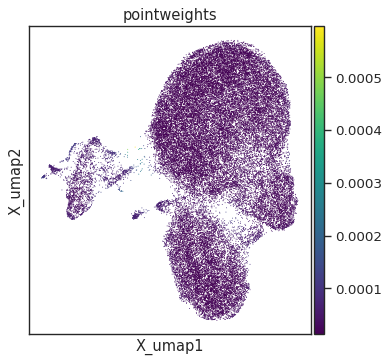

Seeding initial graph...
Clustering...
K-Means clustering ...
Calculating minimum spanning tree...


/home/a.blanc-boekholt/miniconda3/lib/python3.13/site-packages/stream2/plotting/_plot.py:1110: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if ann in adata.obs_keys():


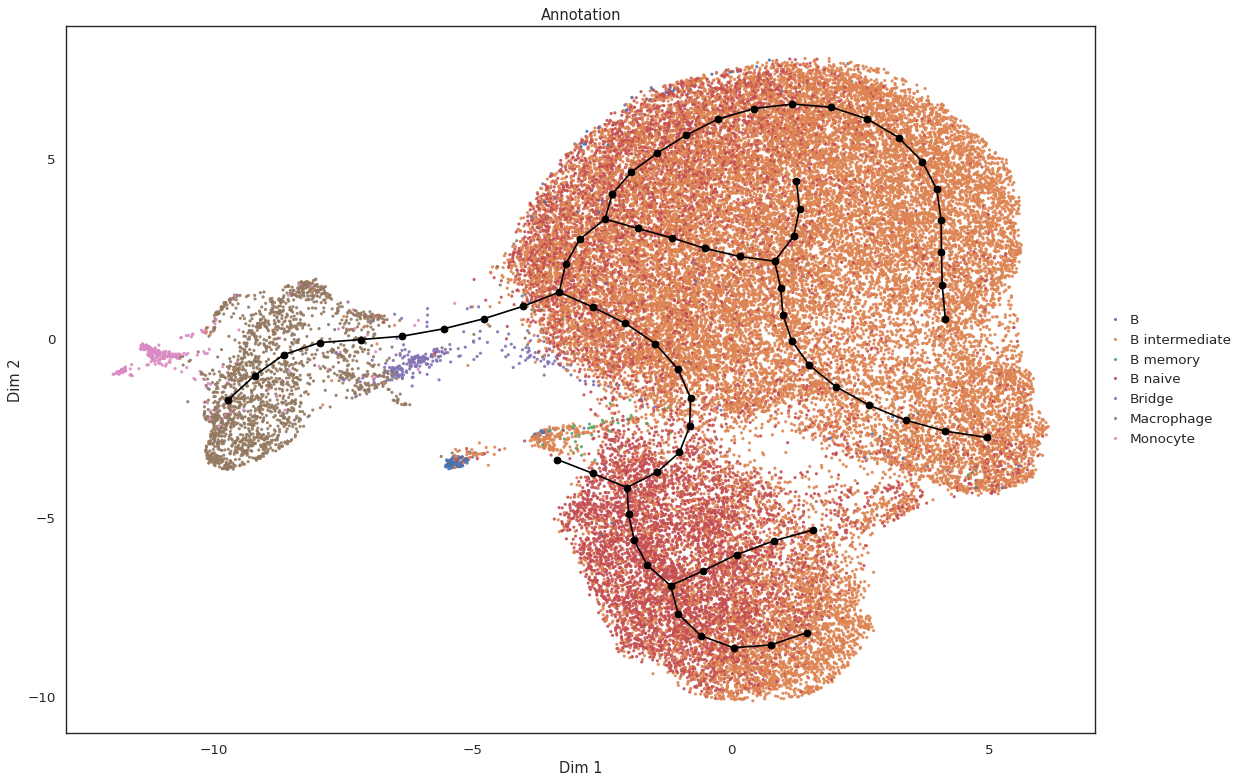

In [78]:
st2.tl.get_weights(adata,bandwidth=.5,method='fft',obsm="X_umap")
sc.pl.embedding(adata,basis='X_umap',color='pointweights')

st2.tl.seed_graph(adata,n_clusters=50,use_weights=True,obsm="X_umap")
st2.tl.learn_graph(adata,n_nodes=70,epg_alpha=0.01,epg_mu=0.05,obsm="X_umap")
st2.pl.graph(adata,key='epg',color=['Annotation'],show_node=1, fig_size=(15,10))

In [10]:
unique_nodes = sorted(adata.obs['epg_node_id'].dropna().unique())

# Mapping node_id in a label (N1, N2...)
epg_to_label = {node: f"N{int(node)}" for node in unique_nodes}

# Macrostate column
adata.obs["macrostate"] = np.nan
adata.obs["macrostate"] = (
    adata.obs["macrostate"]
    .astype("category")
    .cat.add_categories(sorted(epg_to_label.values()))
)

# Assign the macrostate based on the nearest node
for node, label in epg_to_label.items():
    mask = adata.obs['epg_node_id'] == node
    adata.obs.loc[mask, "macrostate"] = label

print(adata.obs['macrostate'].value_counts())

macrostate
N114    889
N30     807
N97     765
N81     755
N28     743
       ... 
N53      91
N60      79
N102     75
N70      48
N23      24
Name: count, Length: 121, dtype: int64


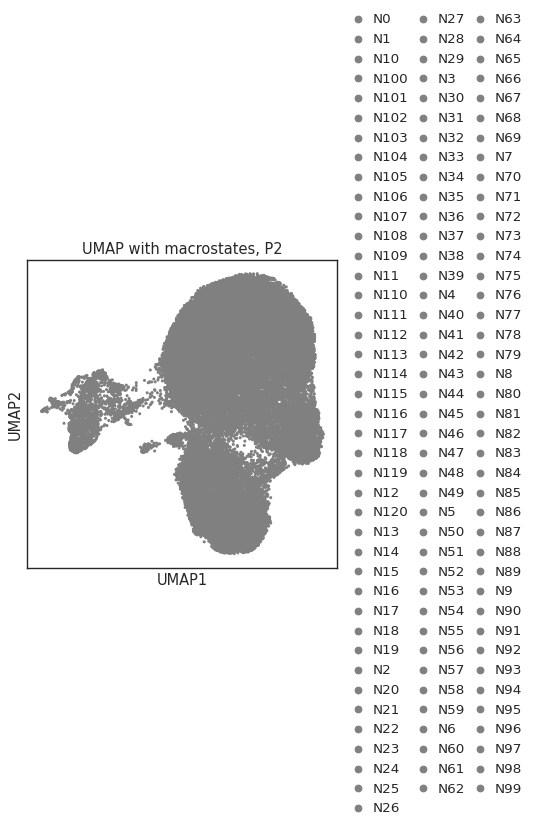

In [13]:
ax = sc.pl.umap(adata,color="macrostate",title=f"UMAP with macrostates, {patient}",size=30,show=False)
#ax.figure.savefig(f"{output_directory}/umap_macrostages_{patient}.png", dpi=150, bbox_inches="tight")

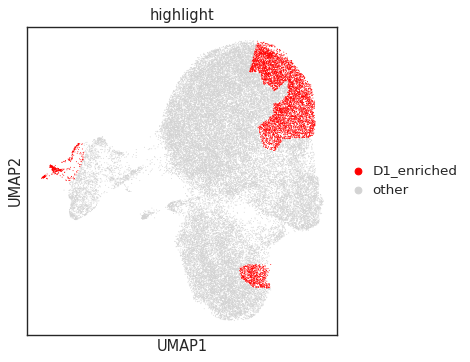

             prop_D1  n_cells  B  B intermediate  B naive  Bridge  Macrophage  \
macrostate                                                                      
N100        0.339806      206  0             199        7       0           0   
N109        0.496386      415  0             400       15       0           0   
N114        0.446569      889  0             878       11       0           0   
N115        0.330882      680  0             545      135       0           0   
N17         0.450704      284  0             282        2       0           0   
N29         0.678947      380  0               4        0       1         115   
N39         0.369159      214  0             201       13       0           0   
N43         0.360000      225  0             213       12       0           0   
N51         0.302281      526  2             461       63       0           0   
N56         0.339572      374  0             331       43       0           0   
N61         0.401055      37

In [14]:
ct = pd.crosstab(adata.obs["macrostate"], adata.obs["timepoint"])

# days proportion (D1)
prop_D1 = ct["D1"] / ct.sum(axis=1)
# Macrostates D1-enriched (>30%) selection
selected_macrostates = prop_D1[prop_D1 > 0.30].index
# Column for UMAP
adata.obs["highlight"] = adata.obs["macrostate"].isin(selected_macrostates)
adata.obs["highlight"] = adata.obs["highlight"].map({True: "D1_enriched", False: "other"})
sc.pl.umap(adata, color="highlight", palette={"D1_enriched": "red", "other": "lightgrey"})
# Macrostates subset
subset = adata.obs.loc[
    adata.obs["macrostate"].isin(selected_macrostates), ["macrostate", "Annotation"]
].copy()
subset["macrostate"] = subset["macrostate"].astype(str)
subset["Annotation"] = subset["Annotation"].astype(str)
# Count cells per macrostates and per celltype 
annotation_counts = subset.groupby(["macrostate", "Annotation"]).size().unstack(fill_value=0)

# DataFrame
prop_D1_selected = prop_D1.loc[annotation_counts.index]
total_counts = subset["macrostate"].value_counts().reindex(annotation_counts.index)
result = pd.DataFrame({
    "prop_D1": prop_D1_selected,
    "n_cells": total_counts})
result = result.join(annotation_counts, how="left")
print(result)

Choose the initial macrostates 
Nodes 115 and 114, and only cells from D1 and annotated as B intermediate

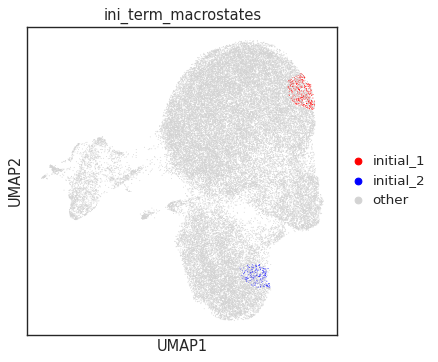

ini_term_macrostates
other        41594
initial_1      397
initial_2      225
Name: count, dtype: int64

In [28]:
adata.obs["ini_term_macrostates"] = "other"
# Initial_1
mask_1 = ((adata.obs["macrostate"] == "N114") & (adata.obs["timepoint"] == "D1"))
# Initial_2
mask_2 = ((adata.obs["macrostate"] == "N115") & (adata.obs["timepoint"] == "D1"))


adata.obs.loc[mask_1, "ini_term_macrostates"] = "initial_1"
adata.obs.loc[mask_2, "ini_term_macrostates"] = "initial_2"

sc.pl.umap( adata, color="ini_term_macrostates", palette={"initial_1": "red", "initial_2": "blue", "other": "lightgrey"})

adata.obs["ini_term_macrostates"].value_counts()

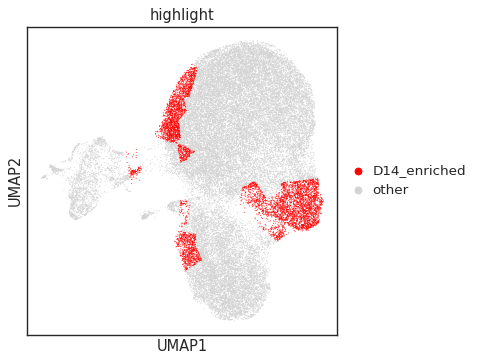

            prop_D14  n_cells   B  B intermediate  B memory  B naive  Bridge  \
macrostate                                                                     
N0          0.576389      144   0             126         0       18       0   
N106        0.562814      199   0             185         0       13       0   
N112        0.438596      114   0               1         0        1     104   
N20         0.498660      373   1             316         0       54       0   
N24         0.533333      390   0             372         0       18       0   
N28         0.481830      743   0             435         0      299       0   
N3          0.514218      422   0              70         0      352       0   
N35         0.508501      647   8             354         0      281       2   
N37         0.630380      395   0             369         0       25       0   
N40         0.437722      281   0             190         1       88       0   
N53         0.461538       91   0       

In [16]:
# days proportion (D14)
prop_D14 = ct["D14"] / ct.sum(axis=1)
# Macrostates D1-enriched (>40%) selection
selected_macrostates = prop_D14[prop_D14 > 0.40].index
# Column for UMAP
adata.obs["highlight"] = adata.obs["macrostate"].isin(selected_macrostates)
adata.obs["highlight"] = adata.obs["highlight"].map({True: "D14_enriched", False: "other"})
sc.pl.umap(adata, color="highlight", palette={"D14_enriched": "red", "other": "lightgrey"})
# Macrostates subset
subset = adata.obs.loc[
    adata.obs["macrostate"].isin(selected_macrostates), ["macrostate", "Annotation"]
].copy()
subset["macrostate"] = subset["macrostate"].astype(str)
subset["Annotation"] = subset["Annotation"].astype(str)
# Count cells per macrostates and per celltype 
annotation_counts = subset.groupby(["macrostate", "Annotation"]).size().unstack(fill_value=0)

# DataFrame
prop_D14_selected = prop_D14.loc[annotation_counts.index]
total_counts = subset["macrostate"].value_counts().reindex(annotation_counts.index)
result = pd.DataFrame({
    "prop_D14": prop_D14_selected,
    "n_cells": total_counts})
result = result.join(annotation_counts, how="left")
print(result)

Choose the initial macrostates 
Nodes 112,3 and 57, and only cells from D14 and annotated as B intermediate

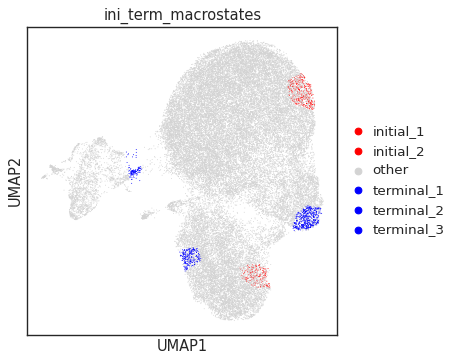

ini_term_macrostates
other         40820
terminal_3      443
initial_1       397
initial_2       225
terminal_2      217
terminal_1      114
Name: count, dtype: int64
timepoint
D14    50
D11    32
D8     24
D4      8
D1      0
Name: count, dtype: int64


In [29]:
adata.obs["ini_term_macrostates"] = adata.obs["ini_term_macrostates"].cat.add_categories(
    ["terminal_1", "terminal_2", "terminal_3"])
# Terminal_1
mask_1 = ((adata.obs["macrostate"] == "N112"))
# Terminal_2
mask_2 = ((adata.obs["macrostate"] == "N3") & (adata.obs["timepoint"] == "D14"))
# Terminal_3
mask_3 = ((adata.obs["macrostate"] == "N57") & (adata.obs["timepoint"] == "D14"))

adata.obs.loc[mask_1, "ini_term_macrostates"] = "terminal_1"
adata.obs.loc[mask_2, "ini_term_macrostates"] = "terminal_2"
adata.obs.loc[mask_3, "ini_term_macrostates"] = "terminal_3"

sc.pl.umap( adata, color="ini_term_macrostates", palette={"initial_1": "red", "initial_2": "red","terminal_1": "blue", 
                                                         "terminal_2": "blue","terminal_3":"blue", "other": "lightgrey" })

print(adata.obs["ini_term_macrostates"].value_counts())

print(adata.obs[adata.obs["ini_term_macrostates"] == "terminal_1"]["timepoint"].value_counts())

In [130]:
fig, ax = plt.subplots(figsize=(15, 10))
sc.pl.umap(adata, color="ini_term_macrostates", ax=ax, show=False, size=20, palette={"initial_1": "red", "initial_2": "red","terminal_1": "blue", 
                                                         "terminal_2": "blue","terminal_3":"blue", "other": "lightgrey" })
plt.suptitle(f"UMAP initial and terminal macrostates, {patient}", fontsize=16, y=1.02)
plt.savefig(f"{output_directory}/graph_macrostates_{patient}.png", dpi=500, bbox_inches='tight')  
plt.close()

In [ ]:
ax = sc.pl.pca(adata,color="macrostate",title=f"PCA with macrostates, {patient}",size=30,show=False)
ax.figure.savefig(f"{output_directory}/pca_macrostages_{patient}.png", dpi=150, bbox_inches="tight")

In [ ]:
ax = sc.pl.tsne(adata,color="macrostate",title=f"T-sne with macrostates, {patient}",size=30,show=False)
ax.figure.savefig(f"{output_directory}/tsne_macrostages_{patient}.png", dpi=150, bbox_inches="tight")

<Axes: title={'center': 'T-sne with macrostates, P2'}, xlabel='tSNE1', ylabel='tSNE2'>

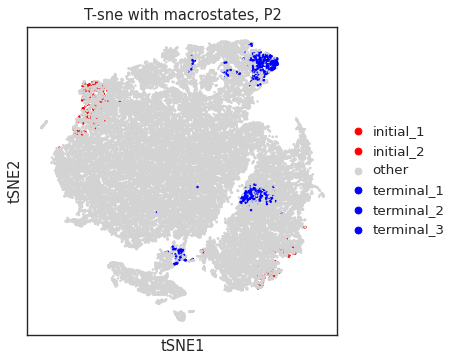

In [22]:
sc.pl.tsne(adata,color="ini_term_macrostates",title=f"T-sne with macrostates, {patient}",size=20,show=False)